<a href="https://colab.research.google.com/github/gonzaloangaut/NeuralNetworks/blob/main/Practicos/redes_neuronales_2023_practico_13_Angaut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PyTorch: Aprendiendo Fashion-MNIST

## Refs.

* https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

* https://github.com/zalandoresearch/fashion-mnist

* https://github.com/pranay414/Fashion-MNIST-Pytorch/blob/master/fashion_mnist.ipynb

## **Ejercicio 1)** Importando librerías

**0)** De ser necesario, **instale PyTorch** escribiendo

    !pip3 install torch torchvision torchaudio torchviz

**1)** Importe las librerías estandard de Python: `os`, `datetime`, `collections` y `pickle`.

**2)** Importe las siguientes librerías third party de Python: `matplotlib.pyplot`, `numpy`, `scipy`, `sklearn`, `pandas`, `dill` y `json`.

**3)** Importe las librerias necesarias de **PyTorch**: `torch` y `torchvision`.

**4)** Importe la librería: `google.colab`.

In [ ]:
# 1.0)
!pip3 install torch torchvision torchaudio torchviz

  Preparing metadata (setup.py) ... done
  Created wheel for torchviz: filename=torchviz-0.0.2-py3-none-any.whl size=4131 sha256=fabe147add63b06e2913abf0ece30a170915f3cb0712089f94a1dc855bd1ee4d
  Stored in directory: /root/.cache/pip/wheels/4c/97/88/a02973217949e0db0c9f4346d154085f4725f99c4f15a87094
Successfully built torchviz


In [ ]:
# 1.1)
import os
import pickle
import datetime
from collections import defaultdict

In [ ]:
# 1.2)
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import scipy as sp
import scipy.linalg as linalg
import sklearn as skl
import pandas as pd
#import dill
import json

In [ ]:
# 1.3)
import torch
import torch.optim as optim
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import datasets
from torchvision import transforms
from torchvision.io import read_image
from torchvision.transforms import ToTensor, Lambda, Compose
#from torchviz import make_dot

In [ ]:
# 1.4)
import google.colab
from google.colab import files

## **Ejercicio 2)**

Bajando y Jugando con el dataset **Fashion-MNIST**.

**1)** Baje y transforme los conjuntos de entrenamiento y testeo de FashionMNIST.

**2)** Explore algunos ejemplos de estos conjuntos. Que formato poseen?

**3)** Visitando la página web de FashionMNIST, cree un diccionario de Python `Dict()` asociando cada categoría a un nombre adecuado de la misma.

**4)** Grafique un mosaico de 3x3 imagenes de FashionMNIST, cada una titulada con su respectiva clasificación

In [ ]:
# 2.1)
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor()
                                #,transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
                               ])

# Download and load the training data
# acá instalamos todo. train es para entrenar y valid para validar
train_set = datasets.FashionMNIST('MNIST_data/', download = True, train = True,  transform = transform)
valid_set = datasets.FashionMNIST('MNIST_data/', download = True, train = False, transform = transform)

100%|██████████| 26421880/26421880 [00:01<00:00, 17819113.51it/s]


Extracting MNIST_data/FashionMNIST/raw/train-images-idx3-ubyte.gz to MNIST_data/FashionMNIST/raw



100%|██████████| 29515/29515 [00:00<00:00, 306203.18it/s]


Extracting MNIST_data/FashionMNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/FashionMNIST/raw



100%|██████████| 4422102/4422102 [00:00<00:00, 5528794.41it/s]


Extracting MNIST_data/FashionMNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/FashionMNIST/raw



100%|██████████| 5148/5148 [00:00<00:00, 5640615.72it/s]

Extracting MNIST_data/FashionMNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/FashionMNIST/raw



In [ ]:
# 2.2)
len(train_set),len(valid_set) # hay 60 mil fotos para entrenar y 10 mil para validar

(60000, 10000)

In [ ]:
i = np.random.randint(len(train_set))
print(f"i={i}")
image,label = train_set[i] # elegimos un numero cualquiera, o sea elegimos una de las fotos del training al azar

i=56883


In [ ]:
label # Cada prenda pertenece a una de 10 categorías enumeradas entre 0 y 9. Acá vemos que label tiene esta foto particular

8

In [ ]:
image #image es una matriz donde los valores tienen que ver con la escala de grises

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0118, 0.0000, 0.1490, 0.4824, 0.5490, 0.2667,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0039, 0.0000, 0.0196, 0.4471, 0.0000, 0.0000, 0.5765,
          0.0824, 0.0000, 0.0118, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0157, 0.0000, 0.3961, 0.1373, 0.0000, 0.0000, 0.0588,
          0.6000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.4588, 0.0000, 0.0000, 0.0000, 0.0000,
          0.5529, 0.1333, 0.0000, 0.0157, 0.0000, 0.0000,

In [ ]:
image.shape #matriz 28x28

torch.Size([1, 28, 28])

In [ ]:
#image.numpy()

In [ ]:
#image.numpy().squeeze()

In [ ]:
image.numpy().squeeze().shape #esto es para sacar el 1 que es de la escala de grises

(28, 28)

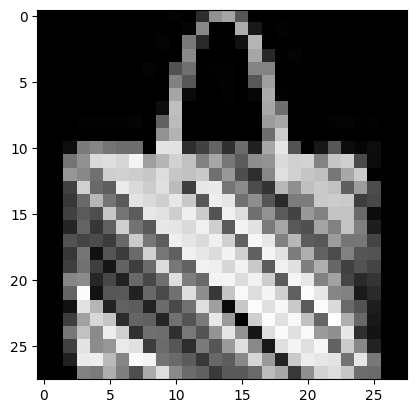

In [ ]:
# Graficamos la imagen
plt.imshow(image.squeeze(),cmap="Greys_r")

In [ ]:
# 2.3)
labels_names = {
    0: "T-Shirt",    # Remera manga corta
    1: "Trouser",    # Pantalon
    2: "Pullover",   # Buzo
    3: "Dress",      # Vestido
    4: "Coat",       # Abrigo
    5: "Sandal",     # Sandalia
    6: "Shirt",      # Remera manga larga
    7: "Sneaker",    # Zapatilla
    8: "Bag",        # Bolso
    9: "Ankle Boot", # Bota
}

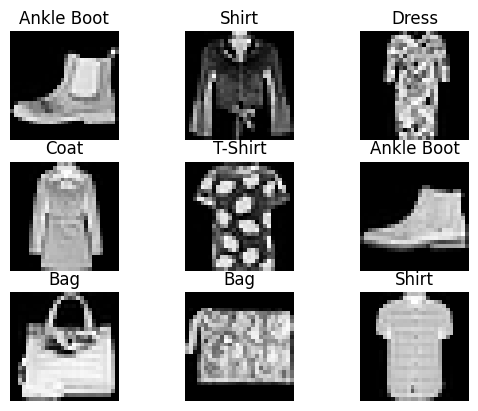

In [ ]:
# 2.4)
figure = plt.figure()
cols,rows = 3,3
for i in range(1,cols*rows+1):
    j = torch.randint(len(train_set),size=(1,)).item() # Los números aleatorios tambien se pueden generar desde pytorch. Util para trabajar en la GPU.
    image,label = train_set[j]
    figure.add_subplot(rows,cols,i)
    plt.title(labels_names[label])
    plt.axis("off")
    plt.imshow(image.squeeze(),cmap="Greys_r")
plt.show()

## Ejercicio 3)

Creando un `DataLoader` para alimentar el modelo con batchs (lotes) de entrenamiento.

**1)** Cree los `DataLoader`s para cada conjunto. Defínalos con un `batch_size` de 64 y con el flag `shuffle` seteado a `True`.

**2)** Use un `DataLoader` creado anteriormente, para explorar algunos elementos del conjunto.

Notar que, el iterador devuelve el batch en un par `(image,label)`.

El objeto `images` es un tensor de dimensiones `(64,1,28,28)`.
El 64 es el tamaño del batch.
El 1 porque hay un solo canal.
Podría haber varios, p. ej. uno por cada color de {Red, Green Blue} en caso que fuesen imagenes a color.
Luego, 28 y 28 porque cada imagen del dataset es de 28 x 28 píxeles.

El objeto `labels` es un tensor de dimensiones `(64,)`.
La $i$-ésima entrada `labels[i]` de `labels` es un número en $\{0,1,...,9\}$ indicando la categoría a la que pertenece la $i$-ésima imagen en el batch, guardada en `images[i]`.

In [ ]:
# 3.1)
# hace lotes para darle de comer a la red neuronal de a 64 imagenes
train_loader = torch.utils.data.DataLoader(train_set, batch_size = 64, shuffle = True)
valid_loader = torch.utils.data.DataLoader(valid_set, batch_size = 64, shuffle = True)

In [ ]:
# 3.2)
train_iter = iter(train_loader) # hago un iterador con toddos los lotes
images,labels = next(train_iter) # da el siguiente lote entero del iterador
print(type(images))
print(images.shape)
print(labels.shape) # hay 64 numeritos ahora

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
torch.Size([64])


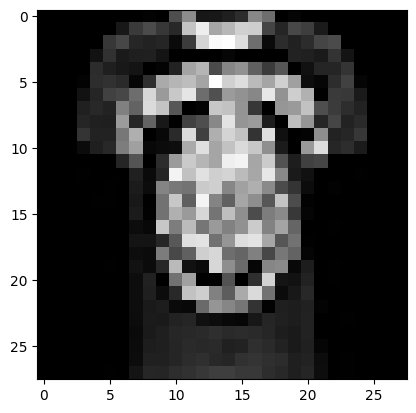

In [ ]:
# Examinamos una imagen del lote
plt.imshow(images[0].numpy().squeeze(),cmap='Greys_r')

In [ ]:
#images[0]

In [ ]:
#images[0].numpy()

In [ ]:
images[0].numpy().shape

(1, 28, 28)

In [ ]:
images[0].numpy().squeeze().shape

(28, 28)

In [ ]:
labels

tensor([0, 3, 7, 3, 9, 9, 8, 8, 3, 7, 9, 7, 0, 1, 3, 8, 5, 2, 2, 3, 0, 0, 1, 7,
        1, 3, 2, 3, 2, 9, 6, 8, 5, 9, 4, 0, 8, 8, 9, 6, 9, 5, 3, 0, 6, 5, 0, 9,
        6, 3, 6, 8, 6, 0, 5, 5, 6, 2, 1, 6, 6, 9, 2, 4])

In [ ]:
labels.numpy()

array([0, 3, 7, 3, 9, 9, 8, 8, 3, 7, 9, 7, 0, 1, 3, 8, 5, 2, 2, 3, 0, 0,
       1, 7, 1, 3, 2, 3, 2, 9, 6, 8, 5, 9, 4, 0, 8, 8, 9, 6, 9, 5, 3, 0,
       6, 5, 0, 9, 6, 3, 6, 8, 6, 0, 5, 5, 6, 2, 1, 6, 6, 9, 2, 4])

In [ ]:
labels.numpy().shape

(64,)

In [ ]:
labels[0]

tensor(0)

## Ejercicio 4)

Defina una red neuronal de 3 capas, una de entrada, una oculta de $n$ neuronas y otra de salida de 10 neuronas.

La capa de entrada debe tener 28x28 neuronas.

En la capa intermedia y la de salida utilice neuronas tipo ReLU.

Capas sucesivas tienen que estar totalmente conectadas entre si.

Agregue un dropout de 0.2 en la capa intermedia y de salida.

In [ ]:
# 4)
# Forma 1
class NeuralNetwork(nn.Module):
    def __init__(self,n,p=0.2): #  inicializa los atributos del objeto que creamos
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten() # "capa" flatten, achata el array
        self.fc1 = nn.Linear(28*28,n) # fc1 = "capa" fully connected 1
        self.relu = nn.ReLU() # "capa" relu
        self.dropo = nn.Dropout(p) # "capa" dropout
        self.fc2 = nn.Linear(n,10) # fc2 = "capa" fully connected 2

    def forward(self, x): # el forward es lo que va a llamar el optimizador cuando quiera evaluar la red
        x = self.flatten(x) # le aplica un flatten a la entrada
        x = self.fc1(x) # fully connected a la primera capa (todas las neuronas conectadas)
        x = self.relu(x) # le aplica relu
        x = self.dropo(x) # le aplica dropout (está a la salida de la capa intermedia). apaga algunas de las neuronas al azar
        x = self.fc2(x) # fully connected a la 2da
        return x

In [ ]:
# Forma 2
#class NeuralNetwork(nn.Module):
#    def __init__(self,n,p=0.2):
#        super(NeuralNetwork, self).__init__()
#        self.flatten = nn.Flatten()
#        self.linear_relu_stack = nn.Sequential(
#            nn.Linear(28*28,n),
#            nn.ReLU(),
#            nn.Dropout(p),
#            nn.Linear(n,10),
#            nn.ReLU(),
#            nn.Dropout(p),
#        )
#    def forward(self, x):
#        x = self.flatten(x)
#        x = self.linear_relu_stack(x)
#        return x

In [ ]:
mi_red = NeuralNetwork(64) # hago mi red
mi_red(image).shape # veamos el shape si alimento mi red

torch.Size([1, 10])

In [ ]:
mi_red(image) # alimento mi red con una imagen . esto seria la salida de la nuerona, hay que normalizar pero lo hace solo dps

tensor([[-0.0160, -0.1783, -0.0071, -0.1595,  0.1242,  0.0826, -0.0339,  0.1539,
         -0.1955, -0.1006]], grad_fn=<AddmmBackward0>)

## Ejercicio 5)

Entrenamos el modelo

**1)** Implemente, en una función, un loop de entrenamiento que recorra los batchs (lotes).

**2)** Implemente, en una función, un loop de prueba o validación que recorra los batchs.

**3)** Inicialize dos `DataLoader`s llamados `train_loader` y `valid_loader` a partir del `train_set` (conjunto de entranmiento) y del `valid_set` (conjunto de validación) de Fashion-MNIST, respectivamente, y que usen batchs de 100 ejemplos.

**4)** Cree una función de pérdida usando la **Entropy-Loss**.

**5)** Cree un optimizador que utilice el método de **Stochastic Gradient Descent** con un learning rate igual a $10^{-3}$.

**6)** Cree una instancia del modelo.

**7)** Especifique en que dispositivo (`device`) va a trabajar: en una **CPU** o en una **GPU**.

**8)** Implemente un loop de entrenamiento y validación que trabaje con el `train_loader` y el `valid_loader`, respectivamente, usando un numero arbitrario de épocas.
Este loop debe guardar en cuatro listas los valores de los promedios del **Entropy-Loss** y las fracciones de clasificaciones correctas o **precisión** (accuracy) sobre el conjunto de **entrenamiento** y el de **validación**, respectivamente.

**IMPORTANTE:** No olvide copiar los batchs al dispositivo de trabajo.

**9)** Entrene y valide el modelo.

**10)** Use las listas del inciso anterior para graficar en función de las épocas la **Entropy-Loss** de **entrenamiento** y de **validación**.
Realize un gráfico análogo pero con la **precisión**.
Discuta y comente, cual es el número óptimo de épocas de entrenamiento?

In [ ]:
# 5.1)
# Definimos la función de entrenamiento (loop de entrenamiento)
def train_loop(dataloader,model,loss_fn,optimizer): # le pasamos un cargador de datos, un modelo, una funcion de perdida (en este caso cross entropy) y optimizador
    # Activamos la maquinaria de entrenamiento del modelo. para calcular los gradientes
    model.train()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss,sum_correct = 0,0
    # Iteramos sobre lotes (batchs)
    for batch, (X, y) in enumerate(dataloader):
        # Copiamos las entradas y las salidas al dispositivo de trabajo
        X = X.to(device)
        y = y.to(device)
        # Calculamos la predicción del modelo y la correspondiente pérdida (error)
        pred = model(X)
        loss = loss_fn(pred,y)
        # Backpropagamos usando el optimizador proveido.
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # Imprimimos el progreso...
        loss_value = loss.item()
        sum_loss += loss_value
        # También calculamos el número de predicciones correctas, y lo acumulamos en un total.
        sum_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
        if batch % 100 == 0:
            current = batch*len(X)
            print(f"@train_loop batch={batch:>5d} loss={loss_value:>7f}  muestras-procesadas=[{current:>5d}/{size:>5d}]")
    avg_loss = sum_loss/num_batches # el error total va a ser el promedio de los errores
    precision = sum_correct/size # la precision va a ser la cantidad de veces que acertó dividido la cantidad total de predicciones
    return avg_loss,precision

# 5.2)
# De manera similar, definimos la función de validación
def valid_loop(dataloader,model,loss_fn):
    # Desactivamos la maquinaria de entrenamiento del modelo
    model.eval()
    # Definimos ciertas constantes
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    sum_loss,sum_correct = 0,0
    # Para testear, desactivamos el cálculo de gradientes.
    with torch.no_grad():
        # Iteramos sobre lotes (batches)
        for X,y in dataloader:
            # Copiamos las entradas y las salidas al dispositivo de trabajo
            X = X.to(device)
            y = y.to(device)
            # Calculamos las predicciones del modelo...
            pred = model(X)
            # y las correspondientes pérdidas (errores), los cuales vamos acumulando en un valor total.
            sum_loss += loss_fn(pred,y).item()
            # También calculamos el número de predicciones correctas, y lo acumulamos en un total.
            sum_correct += (pred.argmax(1) == y).type(torch.float).sum().item() # si el max de la prediccion...
    # Calculamos la pérdida total y la fracción de clasificaciones correctas, y las imprimimos.
    avg_loss = sum_loss/num_batches
    precision = sum_correct/size
    print(f"@valid_loop precision={(100*precision):>0.1f}% avg_loss={avg_loss:>8f}")
    return avg_loss,precision

In [ ]:
# 5.3)
# Creamos los DataLoaders
batch_size = 100
train_loader = DataLoader(train_set, batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=batch_size,shuffle=True)

In [ ]:
# 5.4)
# Creamos una instancia de una función de pérdida, una entropy loss en este caso
loss_fn = nn.CrossEntropyLoss()

In [ ]:
# 5.5)
n = 64
model = NeuralNetwork(n)

In [ ]:
# 5.6)
# Creamos un optimizador, un Stochastic Gradient Descent, en este caso.
learning_rate = 1e-3 # necesario para definir
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)
#optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate,eps=1e-08,weight_decay=0,amsgrad=False)

In [ ]:
# 5.7)
# Determinamos en que dispositivo vamos a trabajar, una CPU o una GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# Pasamos el modelo al dispositivo
model = model.to(device)

In [ ]:
# 5.8) y 5.9)
# Finalmente, entrenamos iterando sobre épocas.
# Además, testeamos el modelo en cada una de ellas.
num_epochs = 30
list_train_avg_loss_incorrecta = []
list_train_avg_loss = []
list_valid_avg_loss = []
list_train_precision_incorrecta = []
list_train_precision = []
list_valid_precision = []
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    train_avg_loss_incorrecta,train_precision_incorrecta = train_loop(train_loader,model,loss_fn,optimizer) #entrenamos
    # el de arriba es el incorrecto pq te tira el error a medida que va entrenando (el error cometido en el 1er ejemplo es mucho mas grande que en
    # el último). una vez que deja de entrenar, debemos validar los datos de entrenamiento para tener la curva que se compara
    train_avg_loss,train_precision = valid_loop(train_loader,model,loss_fn) # ahora validamos los datos de entrenamiento
    valid_avg_loss,valid_precision = valid_loop(valid_loader,model,loss_fn) # validamos los de validación

    #armo listas
    list_train_avg_loss_incorrecta.append(train_avg_loss_incorrecta)
    list_train_avg_loss.append(train_avg_loss)
    list_valid_avg_loss.append(valid_avg_loss)
    list_train_precision_incorrecta.append(train_precision_incorrecta)
    list_train_precision.append(train_precision)
    list_valid_precision.append(valid_precision)
print("Done!")

Epoch 1
-------------------------------
@train_loop batch=    0 loss=2.321517  muestras-procesadas=[    0/60000]
@train_loop batch=  100 loss=2.258680  muestras-procesadas=[10000/60000]
@train_loop batch=  200 loss=2.226881  muestras-procesadas=[20000/60000]
@train_loop batch=  300 loss=2.172585  muestras-procesadas=[30000/60000]
@train_loop batch=  400 loss=2.154130  muestras-procesadas=[40000/60000]
@train_loop batch=  500 loss=2.083821  muestras-procesadas=[50000/60000]
@valid_loop precision=47.3% avg_loss=2.058269
@valid_loop precision=46.7% avg_loss=2.059450
Epoch 2
-------------------------------
@train_loop batch=    0 loss=2.041005  muestras-procesadas=[    0/60000]
@train_loop batch=  100 loss=2.063178  muestras-procesadas=[10000/60000]
@train_loop batch=  200 loss=2.030526  muestras-procesadas=[20000/60000]
@train_loop batch=  300 loss=1.921111  muestras-procesadas=[30000/60000]
@train_loop batch=  400 loss=1.904035  muestras-procesadas=[40000/60000]
@train_loop batch=  500 l

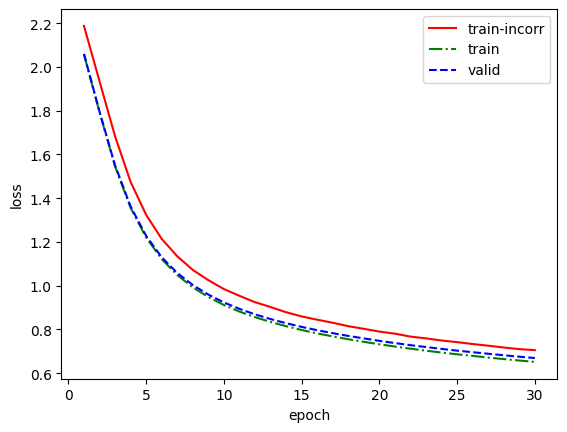

In [ ]:
# 5.10)
plt.xlabel('epoch')
plt.ylabel('loss')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_avg_loss_incorrecta)+1),list_train_avg_loss_incorrecta,label="train-incorr",linestyle='-',c='red')
plt.plot(range(1,len(list_train_avg_loss)+1),list_train_avg_loss,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_avg_loss)+1),list_valid_avg_loss,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()

In [ ]:
"""
Notemos que train incorrect está por encima de valid que está por encima de train. esto debe ser siempre así
"""

'\nNotemos que train incorrect está por encima de valid que está por encima de train. esto debe ser siempre así\n'

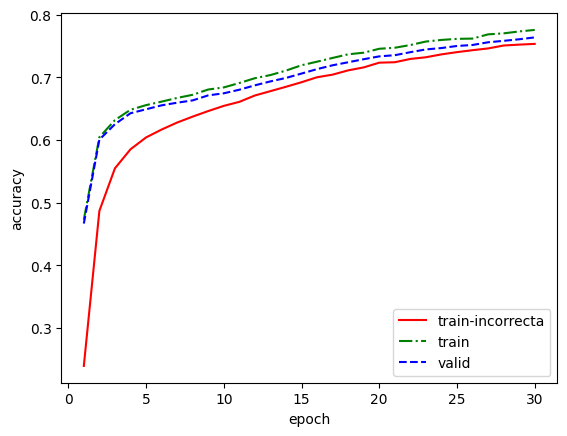

In [ ]:
plt.xlabel('epoch')
plt.ylabel('accuracy')
#plt.xlim(-0.1,5.1)
#plt.ylim(-0.1,1.1)
plt.plot(range(1,len(list_train_precision_incorrecta)+1),list_train_precision_incorrecta,label="train-incorrecta",linestyle='-',c='red')
plt.plot(range(1,len(list_train_precision)+1),list_train_precision,label="train",linestyle='-.',c='green')
plt.plot(range(1,len(list_valid_precision)+1),list_valid_precision,label="valid",linestyle='--',c='blue')
plt.title('')
plt.legend()